In [ ]:
# ============================================================
# NOTEBOOK 01 - CONVERTIDOR BUCK
# Grado de Electrónica - Electrónica de Potencia
# Septiembre/2026 (c)
#
# Objetivos:
#   1. Analizar el convertidor Buck en CCM
#   2. Relacionar las corrientes del inductor y del condensador
#   3. Obtener las expresiones de Vout, Iout y los rizados
#   4. Comparar teoría, simulación numérica en Python y ngspice
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import os

# Configuración de gráficos
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# **El convertidor Buck**



![Figura 1. Convertidor reductor DC/DC](figures/1_buck.png)
![Figura 2. Modelo simplificado](figures/2_simply.png)
![Figura 3. Potencia en S1](figures/3_no_losses.png)


Un **convertidor Buck** es un dispositivo electrónico que
permite obtener una tensión continua de salida menor que la tensión
continua de entrada, $V_{out}=D\,V_{in}$, donde $D$ es un factor cuyo valor está entre 0 y 1, denominado ciclo de trabajo (*duty cycle*). El ciclo de trabajo se define como $D=\frac{T_{ON}}{T}$ donde $T$ es el periodo de conmutación, $T_{ON}=DT$  y  $T_{OFF}=(1-D)T$ son los intervalos durante los cuales el interruptor permanece cerrado ($ON$) y abierto ($OFF$), respectivamente. Los elementos fundamentales del **convertidor Buck** son:

* Interruptor. Controla cuándo la fuente de entrada está conectada al inductor.

*  Diodo. Proporciona un camino para la corriente del inductor cuando el
interruptor se encuentra abierto.

* Inductor. Se opone a cambios bruscos de corriente,$v_L=L\frac{di_L}{dt}$

* Condensador. Se opone a cambios bruscos de tensión, $i_C=C\frac{dv_C}{dt}$, suaviza la tensión.
* Resistor. Representa la carga.


* Cuando el interruptor está cerrado la tensión aplicada al inductor es $v_L=V_{in}-V_{out}$ y como $v_L=L\frac{di_L}{dt}$ tenemos:

$$
\boxed{
\frac{di_L}{dt}
=
\frac{V_{in}-V_{out}}{L}
}
$$

> Si $V_{in}>V_{out}$ entonces $\frac{di_L}{dt}>0$, la corriente del inductor aumenta linealmente (la integral de una constante es una recta).

* Cuando el interruptor se abre el inductor mantiene la continuidad de su corriente ya que el diodo proporciona un camino alternativo. Suponiendo un diodo ideal $v_L=-V_{out}$ y como $L\frac{di_L}{dt}=-V_{out}$ tenemos:

$$
\boxed{
\frac{di_L}{dt}
=
-\frac{V_{out}}{L}
}
$$

> La corriente del inductor cambia de signo disminuyendo linealmente.


# Corriente en el inductor
En **PSS**, la corriente del inductor comienza cada periodo con el mismo valor con el que terminó el periodo anterior, $\Delta i_L=0$

* Durante el intervalo ON, como $V_{out}=DV_{in}$ y $T=1/f$:

$$
\Delta i_{L,ON}
=
\frac{V_{in}-V_{out}}{L}DT
\quad = \quad
\frac{V_{in} ·(1-D)·D}{L·f}
$$

* Durante el intervalo OFF:

$$
\Delta i_{L,OFF}
=
-\frac{V_{out}}{L}(1-D)T
\quad = \quad \frac{V_{in} ·(1-D)·D}{L·f}
$$

A manera de comprobación, en régimen estacionario (**PSS**) $\Delta i_{L,ON}+\Delta i_{L,OFF}=0$ por lo que:

$$
\frac{V_{in}-V_{out}}{L}DT
-
\frac{V_{out}}{L}(1-D)T=0
$$

Después de simplificar se tiene

$$
\boxed{
V_{out}=DV_{in}
}
$$

La corriente del inductor presenta una ondulación $\Delta i_L=i_{L,max}-i_{L,min}$, que depende de $V_{in}$, $D$, $L$ y $f$. Si $I_{L,min}>0$, es decir, la corriente en **PSS** nunca llega a cero, se dice que el convertidor trabaja en modo de $\text{Conducción Continua (CCM)}$. Para este circuito, el valor medio en **PSS** de $i_L$ es $\left\langle i_L \right\rangle = I_{out}$, ya que en régimen permanente la corriente a través del condensador es cero. Para el Buck ideal, se desprecian las pérdidas en el convertidor, usando el balance de potencia ideal, $P_{in}=P_{out}$, por lo que $V_{in}I_{in}=V_{out}I_{out},$ de donde $I_{out}=\frac{1}{D}I_{in}$.

# Corriente del condensador

* Durante el intervalo ON, la corriente del inductor aumenta linealmente:

$$
i_L(t)
=
I_{L,min}
+
\frac{\Delta i_L}{T_{on}}t
$$

En CCM $I_{L,min} = I_{out}-\frac{\Delta i_L}{2}$ Por tanto:

$$
i_C(t)
=
-\frac{\Delta i_L}{2}
+
\frac{\Delta i_L}{T_{on}}t
$$

La corriente del condensador cambia de signo dentro del intervalo. Esto significa que durante ON el condensador inicialmente se
descarga y posteriormente se carga.

* Durante el intervalo OFF, la corriente del inductor disminuye linealmente.Si utilizamos un tiempo local $t'$ que comienza al principio del intervalo OFF, $
0\leq t'<T_{off}$ tenemos:

$$
i_L(t')
=
I_{L,max}
-
\frac{\Delta i_L}{T_{off}}t'
$$

Por tanto:

$$
i_C(t')
=
\frac{\Delta i_L}{2}
-
\frac{\Delta i_L}{T_{off}}t'
$$

Durante este intervalo el condensador primero se carga y después
se descarga.

# Tensión en el condensador

La tensión de salida es el resultado de integrar la corriente que circula por el condensador $i_C(t)=C\frac{dv_{out}(t)}{dt}$, así:

$$
\boxed{
v_{out}(t)
=
v_{out}(0)
+
\frac{1}{C}
\int_0^t i_C(\tau)\,d\tau
}
$$


En el convertidor Buck, el condensador está conectado en paralelo
con la carga. La corriente del condensador es la diferencia entre la corriente
del inductor y la corriente de carga, $i_C(t)=i_L(t)-i_{out}(t)$. En régimen estacionario, podemos aproximar $i_{out}(t)\approx I_{out}$ por lo que $i_C(t)=i_L(t)-I_{out}$. Esta relación permite determinar el comportamiento del condensador.

* Si $i_L>I_{out}$ entonces $i_C>0$ y el condensador se carga: $\quad \quad \quad \frac{dv_{out}}{dt}>0$

* Si $i_L<I_{out}$ entonces $i_C<0$ y el condensador se descarga: $\quad \quad \frac{dv_{out}}{dt}<0$

* Finalmente, cuando $i_L=I_{out}$ tenemos $i_C=0$ y en el condensador $\frac{dv_{out}}{dt}=0$

Por tanto, los máximos y mínimos de la tensión de salida aparecen
cuando la corriente del inductor cruza su valor medio.

## Ondulación de tensión del condensador

La ondulación de tensión, $\Delta V_{out}=V_{out,max}-V_{out,min}$  depende de la carga eléctrica que entra o sale del condensador $\Delta V_{out}=\frac{\Delta Q}{C}$. Gráficamente, la carga $\Delta Q$ equivale al área del triángulo formado por la corriente $i_c(t)$ sobre el eje cero (cuando la corriente del inductor supera el valor medio $I_o$). La **base del triángulo** es todo el semiperiodo positivo, que dura medio periodo completo, $\frac{T}{2}$. La **altura del triángulo** es el valor máximo de la corriente sobre el eje, equivalente a medio rizado de corriente, $\frac{\Delta i_L}{2}$.Calculando el área de dicho triángulo ($\text{Base} \times \text{Altura} / 2$):

$$
\Delta Q
= \frac{1}{2} · \frac{T}{2} · \frac{\Delta i_L }{2} \quad=\quad \frac{T · \Delta i_L}{8}
$$

Sustituyendo $\Delta Q$ en la fórmula del condensador y recordando que el periodo es el inverso de la frecuencia:

$$
\Delta V_{out}
=
\frac{\Delta i_L}{8Cf}
$$


Para un Buck ideal en CCM $\Delta i_L=\frac{V_{in}D(1-D)}{Lf}$ y considerando que $V_{out}=DV_{in}$, se tiene:

$$
\boxed{
\Delta V_{out}
=
\frac{V_{out}(1-D)}
{8LCf^2}
}
$$

Estas expresiones suponen un condensador ideal y despreciamos
la resistencia serie equivalente, ESR.

# Ejemplo. Considerar un **convertidor Buck** con $V_{in}=8\,V$, $D=0.5$, $T=10\,\mu s$, $L=100\,\mu H$, $C=1\,\mu F$ y $R=8\,\Omega$. Los tiempos durante los que el interruptor está cerrado  y abierto son  $T_{ON}=DT=5\,\mu s$,  $T_{OFF}$=$(1-D)T$=$5\,\mu s$, respectivamente, con lo cual $f=\frac{1}{T}=100\,kHz$.

In [ ]:
# Parámetros del convertidor Buck
Vin         = 8.0          # V
D           = 0.5            # Duty cycle
Tsw         = 10e-6        # s
fs          = 1 / Tsw       # Hz

L           = 100e-6         # H
C           = 1e-6           # F
R           = 8.0            # ohm

Ton         = D * Tsw
Toff        = (1 - D) * Tsw

In [ ]:
# Impresión de parámetros
print(f"Vin  = {Vin:.2f} V")
print(f"D    = {D:.2f}")
print(f"fs   = {fs/1e3:.1f} kHz")
print(f"Ton  = {Ton*1e6:.2f} us")
print(f"Toff = {Toff*1e6:.2f} us")
print(f"L    = {L*1e6:.1f} uH")
print(f"C    = {C*1e6:.1f} uF")
print(f"R    = {R:.1f} ohm")

Vin  = 8.00 V
D    = 0.50
fs   = 100.0 kHz
Ton  = 5.00 us
Toff = 5.00 us
L    = 100.0 uH
C    = 1.0 uF
R    = 8.0 ohm


In [ ]:
# Resultados teóricos del Buck ideal, Vout/Iout
Vout_ideal = D * Vin            # Tensión media de salida. Vout = D * Vin
Iout_ideal = Vout_ideal / R     # Corriente media. Iout = Vout / R

# Ripple de corriente del inductor.
delta_iL   = (Vin - Vout_ideal) * Ton / L

I_L_min    = Iout_ideal - delta_iL / 2
I_L_max    = Iout_ideal + delta_iL / 2

# Ripple de tensión del condensador
delta_Vout = delta_iL / (8 * fs * C)
# Vout_min = Vout - delta_Vout / 2
# Vout_max = Vout + delta_Vout / 2

In [ ]:
print("===== RESULTADOS TEÓRICOS =====")
print(f"Vout medio       = {Vout_ideal:.4f} V")
print(f"Iout medio       = {Iout_ideal:.4f} A")
print(f"Delta iL         = {delta_iL:.4f} A")
print(f"I_L mínimo       = {I_L_min:.4f} A")
print(f"I_L máximo       = {I_L_max:.4f} A")
print(f"Delta Vout aprox = {delta_Vout:.4f} V")

===== RESULTADOS TEÓRICOS =====
Vout medio       = 4.0000 V
Iout medio       = 0.5000 A
Delta iL         = 0.2000 A
I_L mínimo       = 0.4000 A
I_L máximo       = 0.6000 A
Delta Vout aprox = 0.2500 V


In [ ]:
# Analizar un periodo en PSS
# Tiempo
t           = np.linspace(0, Tsw, 1000)
# Corriente del inductor
iL          = np.zeros_like(t)
# on
mask_on     = t < Ton
iL[mask_on] = (I_L_min + (delta_iL / Ton) * t[mask_on])
# off
t_off       = t[~mask_on] - Ton
iL[~mask_on] = (I_L_max - (delta_iL / Toff) * t_off)

# Corriente del condensador
iC = iL - Iout_ideal
# Integración de la corriente del condensador
dt = t[1] - t[0]
v_ripple = np.cumsum(iC) * dt / C

# Centrar el ripple alrededor de cero
v_ripple -= np.mean(v_ripple)

vout_t = Vout_ideal + v_ripple

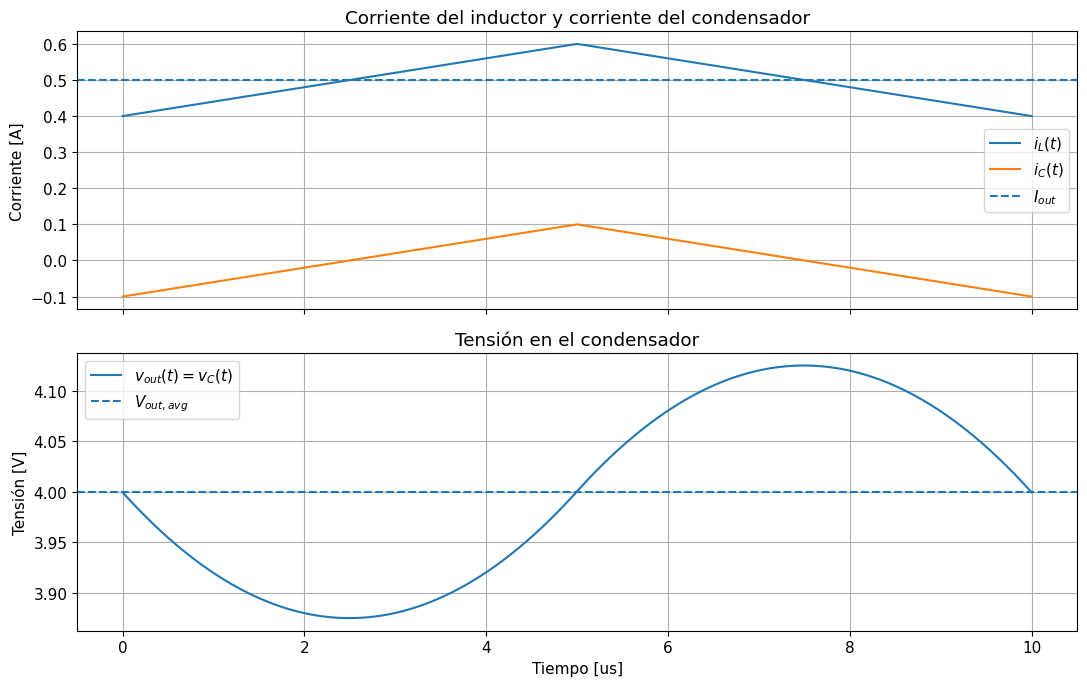

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Corrientes
ax[0].plot(t * 1e6, iL, label=r"$i_L(t)$")
ax[0].plot(t * 1e6, iC, label=r"$i_C(t)$")
ax[0].axhline(Iout_ideal, linestyle="--", label=r"$I_{out}$")

ax[0].set_ylabel("Corriente [A]")
ax[0].set_title("Corriente del inductor y corriente del condensador")
ax[0].grid(True)
ax[0].legend()

# Tensión
ax[1].plot(t * 1e6, vout_t, label=r"$v_{out}(t)=v_C(t)$")
ax[1].axhline(Vout_ideal, linestyle="--", label=r"$V_{out,avg}$")

ax[1].set_xlabel("Tiempo [us]")
ax[1].set_ylabel("Tensión [V]")
ax[1].set_title( "Tensión en el condensador")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

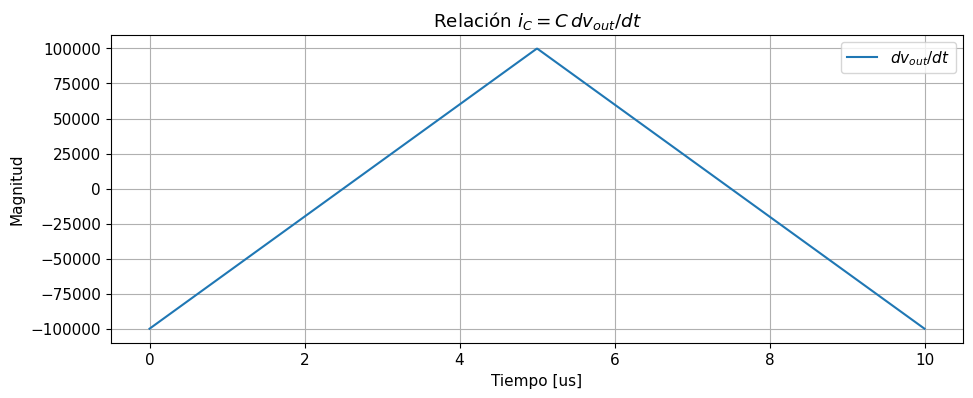

In [ ]:
# Verificación directa: iC = C * dvout/dt

dvout_dt = iC / C

plt.figure(figsize=(11, 4))
# plt.plot(t * 1e6, iC,  label=r"$i_C(t)$")
plt.plot(t * 1e6,  dvout_dt, label=r"$dv_{out}/dt$")

plt.xlabel("Tiempo [us]")
plt.ylabel("Magnitud")
plt.title(r"Relación $i_C=C\,dv_{out}/dt$")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Simulación numérica del Buck ideal

t_stop    = 2e-3
dt        = 0.2e-6

t         = np.arange(0, t_stop + dt, dt)

iL        = np.zeros_like(t)
vout      = np.zeros_like(t)
gate      = np.zeros_like(t)

for k in range(len(t) - 1):
    # Estado del interruptor
    on      = (t[k] % Tsw) < Ton
    gate[k] = 1 if on else 0
    # Ecuación del inductor
    if on:
      di_dt = (Vin - vout[k]) / L
    else:
      di_dt = -vout[k] / L
    # Ecuación del condensador
    dv_dt   = (iL[k] - vout[k] / R) / C
    # Integración Euler
    iL[k+1] = iL[k] + di_dt * dt
    vout[k+1] = vout[k] + dv_dt * dt

gate[-1] = gate[-2]

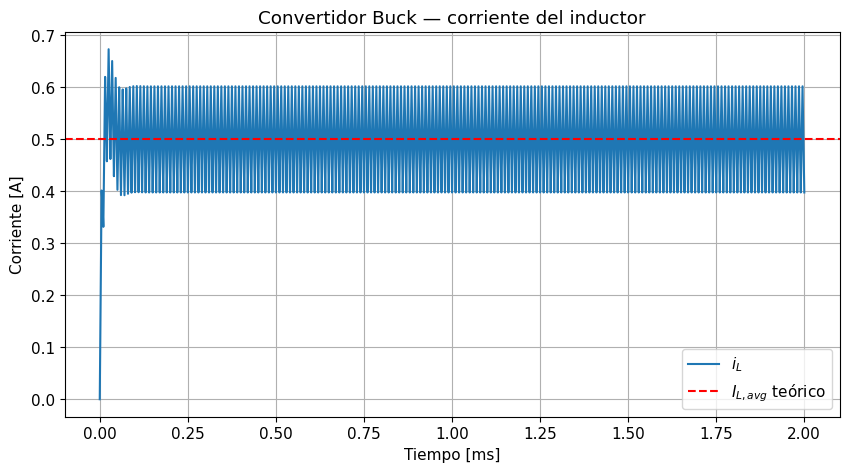

In [ ]:
plt.plot(t * 1e3, iL, label=r"$i_L$")
plt.axhline(Iout_ideal, linestyle="--", label=r"$I_{L,avg}$ teórico",color='r')
plt.xlabel("Tiempo [ms]")
plt.ylabel("Corriente [A]")
plt.title("Convertidor Buck — corriente del inductor")
plt.grid(True)
plt.legend()
plt.show()

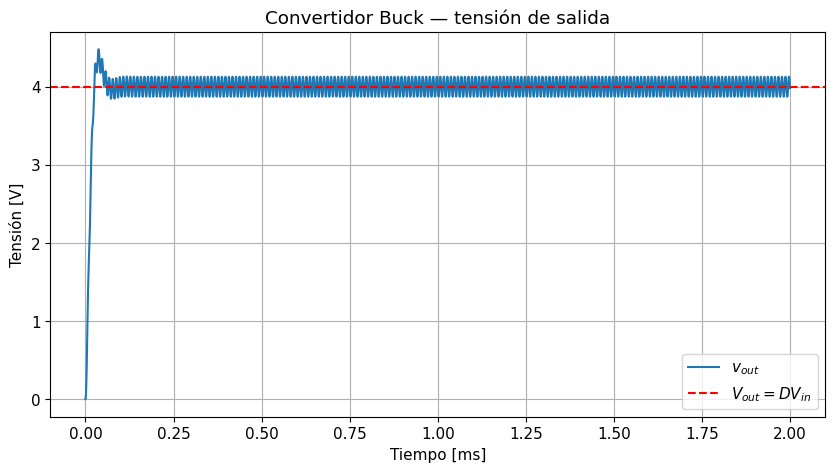

In [ ]:
plt.plot(t * 1e3, vout, label=r"$v_{out}$")
plt.axhline(Vout_ideal, linestyle="--", label=r"$V_{out}=D V_{in}$", color ='r')

plt.xlabel("Tiempo [ms]")
plt.ylabel("Tensión [V]")
plt.title("Convertidor Buck — tensión de salida (python)")
plt.grid(True)
plt.legend()
plt.show()

# **Simulación SPICE**

In [ ]:
# Instalar ngspice para linux dentro del entorno COLAB
!apt-get update -qq
!apt-get install -y ngspice

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  ngspice-doc
The following NEW packages will be installed:
  ngspice
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 2,352 kB of archives.
After this operation, 7,972 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 ngspice amd64 36+ds-1ubuntu0.1 [2,352 kB]
Fetched 2,352 kB in 0s (9,305 kB/s)
Selecting previously unselected package ngspice.
(Reading database ... 118337 files and directories currently installed.)
Preparing to unpack .../ngspice_36+ds-1ubuntu0.1_amd64.deb ...
Unpacking ngspice (36+ds-1ubuntu0.1) ...
Setting up ngspice (36+ds-1ubuntu0.1) ...
Processing triggers for man-db (2.10.2-1) 

In [ ]:

# Comprobar la instalación solicitando la versión ngspice instalada
!ngspice -v

******
** ngspice-36 : Circuit level simulation program
** The U. C. Berkeley CAD Group
** Copyright 1985-1994, Regents of the University of California.
** Copyright 2001-2020, The ngspice team.
** Please get your ngspice manual from http://ngspice.sourceforge.net/docs.html
** Please file your bug-reports at http://ngspice.sourceforge.net/bugrep.html
** Creation Date: Mon Mar 11 21:44:53 UTC 2024
******


In [ ]:
netlist_buck = r"""
* CONVERTIDOR BUCK IDEAL

.title Buck converter - ideal switch
* Parámetros
.param Vinval = 8
.param Rval   = 8
.param Lval   = 100u
.param Cval   = 1u

.param Tsw    = 10u
.param Duty   = 0.5

* Fuente de entrada
V1 in 0 DC {Vinval}
* Señal de control
Vgate gate 0 PULSE(0 5 0 10n 10n {Duty*Tsw} {Tsw})

* Interruptor ideal
S1 in sw gate 0 SWMOD
* Inductor
L1 sw out {Lval}
* Carga
R1 out 0 {Rval}
* Condensador de salida
C1 out 0 {Cval}
* Diodo de rueda libre. Ánodo  -> GND y Cátodo -> nodo sw
D1 0 sw DIDEAL

* Modelo
.model DIDEAL D(IS=1 N=1 RS=1m BV=100)
.model SWMOD SW(RON=1m ROFF=1Meg VT=2 VH=0.1)
* Análisis transitorio
.tran 0.1u 2m
.control
run
set filetype=ascii
wrdata buck_results.txt time v(out) i(L1)
.endc
.end
"""

In [ ]:
# Crear netlist
with open("buck.sp", "w") as f:
    f.write(netlist_buck)
print("Netlist creado: buck.sp")

Netlist creado: buck.sp


In [ ]:
# Ejecutar ngspice
result = subprocess.run(["ngspice", "-b", "buck.sp"], capture_output=True, text=True)
print(result.stdout)

if result.stderr:
    print("Mensajes:")
    print(result.stderr)

print("Código de salida:", result.returncode)

if result.returncode == 0:
    print("Simulación completada correctamente.")


No compatibility mode selected!


Circuit: Buck converter - ideal switch

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
in                                           8
gate                                         0
sw                                 2.14201e-07
out                                2.14201e-07
l1#branch                          2.67751e-08
vgate#branch                                 0
v1#branch                               -8e-06


No. of Data Rows : 28205

Mensajes:
Note: No ".plot", ".print", or ".fourier" lines; no simulations run

Código de salida: 1


In [ ]:
data = pd.read_csv("buck_results.txt", sep=r"\s+", engine="python", header=None)
data.head()

,0,1,2,3,4,5
0,0.000000e+00,0.000000e+00,0.000000e+00,2.142008e-07,0.000000e+00,2.677511e-08
1,1.000000e-10,1.000000e-10,1.000000e-10,2.142008e-07,1.000000e-10,2.677511e-08
2,2.000000e-10,2.000000e-10,2.000000e-10,2.142008e-07,2.000000e-10,2.677511e-08
3,4.000000e-10,4.000000e-10,4.000000e-10,2.142008e-07,4.000000e-10,2.677511e-08
4,8.000000e-10,8.000000e-10,8.000000e-10,2.142008e-07,8.000000e-10,2.677511e-08


In [ ]:
data.columns = ["time", "NADA1", "NADA2",  "vout",  "NADA3", "iL"]
data.tail()

,time,NADA1,NADA2,vout,NADA3,iL
28200,0.002,0.002,0.002,4.011862,0.002,0.412985
28201,0.002,0.002,0.002,4.002868,0.002,0.408968
28202,0.002,0.002,0.002,3.993586,0.002,0.404961
28203,0.002,0.002,0.002,3.984022,0.002,0.400963
28204,0.002,0.002,0.002,3.977769,0.002,0.398415


In [ ]:
# Comparación entre teoría y simulación
# Utilizamos solamente el último 20 % de la simulación
# para representar el régimen estacionario.

mask = data["time"] > 1.6e-3

vout_avg_sim = data.loc[mask, "vout"].mean()
iL_avg_sim = data.loc[mask, "iL"].mean()

iL_min_sim = data.loc[mask, "iL"].min()
iL_max_sim = data.loc[mask, "iL"].max()

vout_min_sim = data.loc[mask, "vout"].min()
vout_max_sim = data.loc[mask, "vout"].max()

In [ ]:
print("========== TEORÍA ==========")
print(f"Vout = {Vout_ideal:.4f} V")
print(f"Iout = {Iout_ideal:.4f} A")
print(f"Delta iL = {delta_iL:.4f} A")

print("\n======= NGSPICE =======")
print(f"Vout medio = {vout_avg_sim:.4f} V")
print(f"IL medio   = {iL_avg_sim:.4f} A")
print(f"IL mínimo  = {iL_min_sim:.4f} A")
print(f"IL máximo  = {iL_max_sim:.4f} A")
print(f"Delta iL   = "  f"{iL_max_sim-iL_min_sim:.4f} A")
print(f"Vout min   = {vout_min_sim:.4f} V")
print(f"Vout max   = {vout_max_sim:.4f} V")

========== TEORÍA ==========
Vout = 4.0000 V
Iout = 0.5000 A
Delta iL = 0.2000 A

======= NGSPICE =======
Vout medio = 4.0034 V
IL medio   = 0.5002 A
IL mínimo  = 0.3983 A
IL máximo  = 0.6026 A
Delta iL   = 0.2043 A
Vout min   = 3.8771 V
Vout max   = 4.1297 V


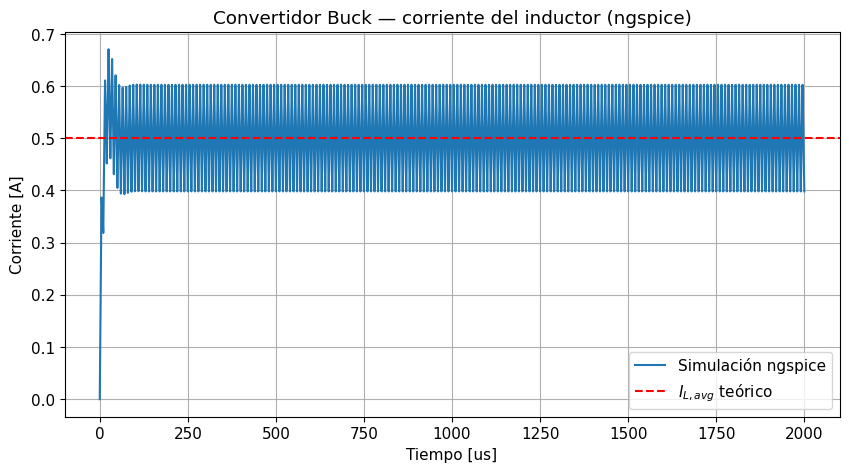

In [ ]:
plt.plot(data["time"] * 1e6, data["iL"], label="Simulación ngspice")
plt.axhline(Iout_ideal, linestyle="--", label=r"$I_{L,avg}$ teórico", color='r')
plt.xlabel("Tiempo [us]")
plt.ylabel("Corriente [A]")
plt.title("Convertidor Buck — corriente del inductor (ngspice)")
plt.grid(True)
plt.legend()
plt.show()

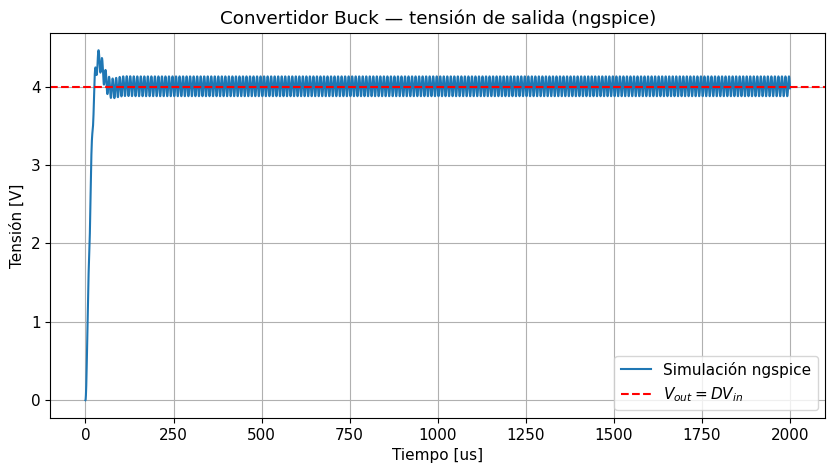

In [ ]:
plt.plot(data["time"] * 1e6, data["vout"], label="Simulación ngspice")
plt.axhline(Vout_ideal, linestyle="--", label=r"$V_{out}=D V_{in}$", color='r')
plt.xlabel("Tiempo [us]")
plt.ylabel("Tensión [V]")
plt.title("Convertidor Buck — tensión de salida (ngspice)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Construcción del modelo triangular teórico de iL

# Elegimos un periodo situado en régimen estacionario
T0 = 1.8e-3
T1 = T0 + Tsw

mask_period = ( (t >= T0) &  (t <= T1))

t_period = t[mask_period]
i_period = iL[mask_period]

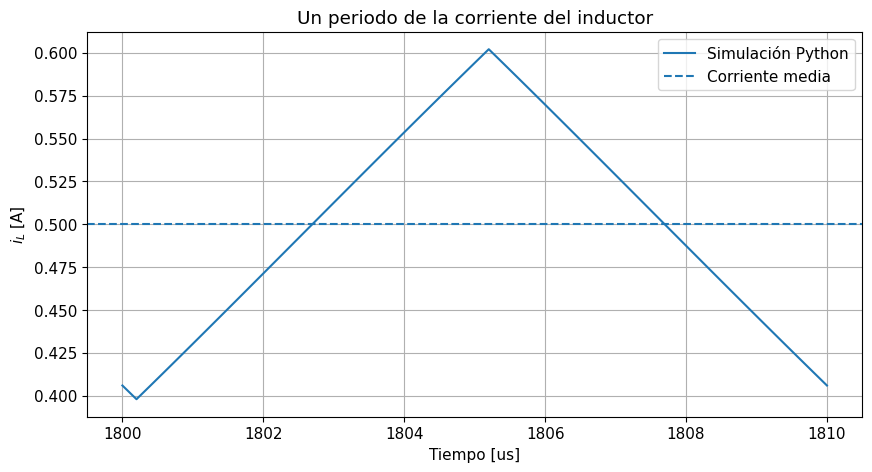

In [ ]:
plt.plot(t_period * 1e6, i_period, label="Simulación Python")

plt.axhline(Iout_ideal, linestyle="--", label="Corriente media")

plt.xlabel("Tiempo [us]")
plt.ylabel(r"$i_L$ [A]")
plt.title("Un periodo de la corriente del inductor")
plt.grid(True)
plt.legend()

plt.show()